In [4]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage, BaseMessage

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

import os
from dotenv import load_dotenv
load_dotenv()

True

In [43]:
llm = ChatOpenAI(
    model="openai/gpt-oss-20b",
    api_key=os.getenv("Grok_Api_key"),
    base_url="https://api.groq.com/openai/v1"
)

In [44]:
# State
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage], add_messages]

# Messages naam ki aik list banao jisme conversation ke tamam messages store hon, 
# aur jab naye messages aayen to add_messages unko purane messages ke sath properly 
# add kar de.

# list[BaseMessage] → messages mein messages ki list hogi.
# Annotated[..., add_messages] → LangGraph ko batata hai ke is field ko update karte waqt add_messages reducer use karo.
# add_messages → naye messages ko purani conversation ke saath merge karta hai, aur message IDs ki basis par existing message ko update bhi kar sakta hai.

In [45]:
# Chat Node
def chat_node(state:ChatState):
    decision = interrupt({
        'type':'approval',
        'reson': 'model is about to answer a user question.',
        'question': state['messages'][-1].content,
        'instruction':'Approve this question? yes/no'
    })

    if decision['approved'] == 'no':
        return {'messages': [AIMessage(content='Not approved.')]}

    else:
        response = llm.invoke(state['messages'])
        return {'messages':[response]}

In [46]:
# Graph
graph = StateGraph(ChatState)

# Node
graph.add_node('chat', chat_node)

# Edge
graph.add_edge(START, 'chat')
graph.add_edge('chat', END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

app = graph.compile(checkpointer=checkpointer)

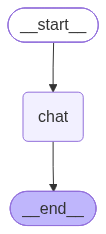

In [47]:
app

In [48]:
# Create a new thread id for this conversation
config = {'configurable': {'thread_id':'1'}}

# User asks a question
initial_input = {'messages': [('user', "Explain gradient descent in very simple terms.")]}

# invoke
result = app.invoke(initial_input, config=config)

In [49]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='d2062c55-fafc-4d59-9d31-cf2aa94f8ead')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reson': 'model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='536f94cd5a6d404e9627fb4527bed63e')]}

In [50]:
message = result['__interrupt__'][0].value

message

{'type': 'approval',
 'reson': 'model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [51]:
user_input = input(f"\nBackend message -{message} \n Approve this questioin? (y/n): ")

In [52]:
final_result = app.invoke(
    Command(resume= {'approved':user_input}),
    config=config
)

In [53]:
print(final_result)

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='d2062c55-fafc-4d59-9d31-cf2aa94f8ead'), AIMessage(content="**Gradient descent** is just a fancy way of saying “keep moving downhill until you hit the lowest point.”  \nHere’s the picture:\n\n1. **The hill**  \n   Imagine a 3‑D landscape (like a bowl or a hill). In machine‑learning terms, that landscape is a *loss function* that tells you how bad a particular choice of numbers (the “parameters” of your model) is. The lower the point, the better the choice.\n\n2. **Your starting point**  \n   You pick some random spot on the hill. This is the initial guess for your parameters.\n\n3. **The slope (gradient)**  \n   From that spot you look in all directions and find which way is steepest downhill. That direction is given by the *gradient*—the math term for “slope in all directions.”\n\n4. **Take a step**  \n   You step a little bit downhill in that direction. 